In [1]:
import os
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scripts.train_model import circuit_training, train_five_times
from scr.qsvdd_core.data_loader import QuantumDataLoader
from scripts.test_model import test, mean_auc
import json

In [2]:
n_train = 0 ; latent_dim = 3
learning_rate = 0.001

In [3]:
print("Diretório atual:", os.getcwd())
print("Arquivos nesta pasta:", os.listdir())

Diretório atual: D:\projects\QSVDD2\notebooks
Arquivos nesta pasta: ['circuit_visualization.ipynb', 'noise_data_visualization.ipynb', 'original_qcnn_experiments', 'training_test_data.ipynb', 'training_test_data_with_pca.ipynb', 'visualization.ipynb']


In [4]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset carregado com sucesso!\n")
print("First 5 records:\n", df.head())

Dataset carregado com sucesso!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141

In [5]:
loader = QuantumDataLoader()

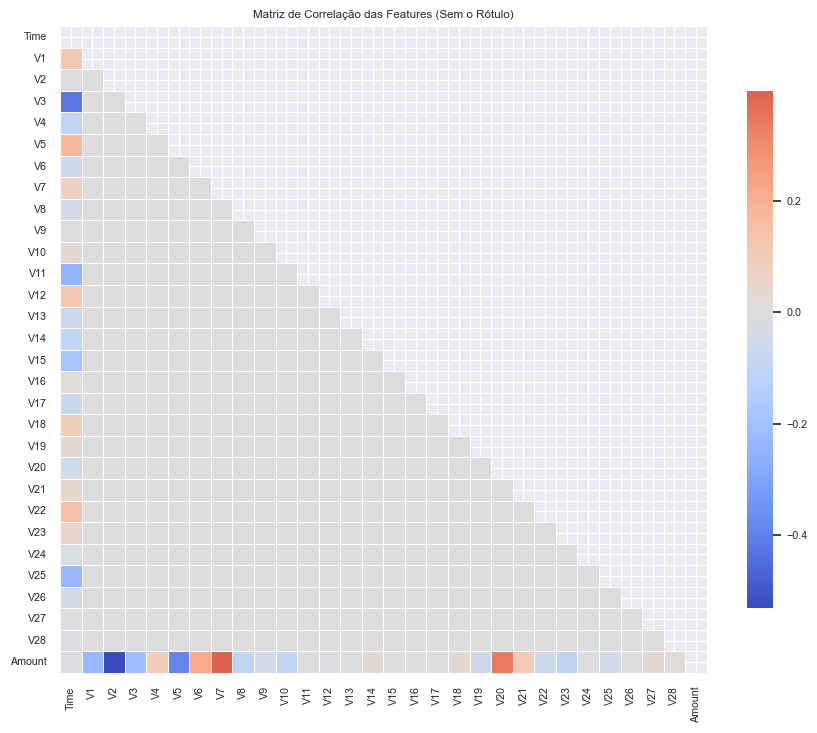

In [6]:
loader.plot_correlation_matrix(df)

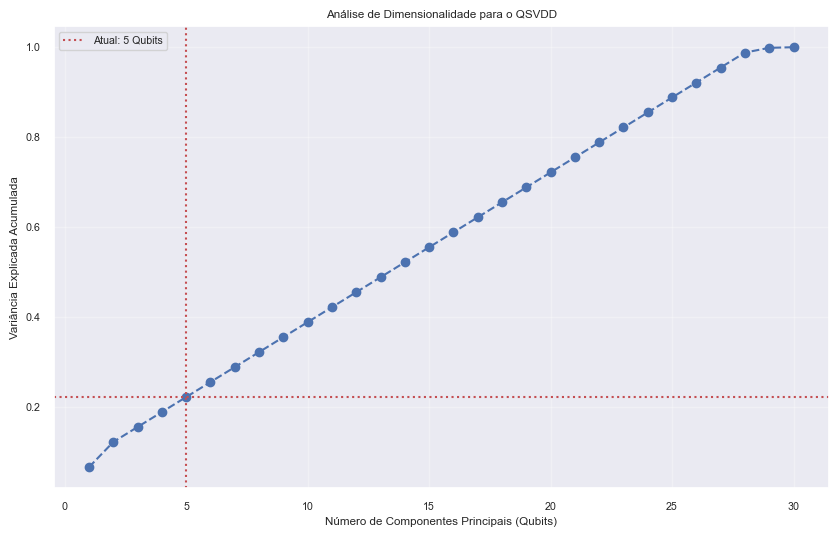

Variância com 5 qubits: 22.14%


In [7]:
loader.plot_explained_variance(df)

In [8]:
X_quantum, y = loader.prepare_pca_data(df)

print(f"Features para o circuito: {X_quantum.shape}") # Deve mostrar (n_linhas, 32)
print(f"Labels: {y.shape}")

Explained Variance Ratio:  [0.06527521 0.05612313 0.03333333 0.03333333 0.03333333]
Singular Values:  [746.80996609 692.47948309 533.67312093 533.67312093 533.67312093]
Features para o circuito: (284807, 5)
Labels: (284807,)
